In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.stats import skew

import sys
sys.path.append("../")
from src.generative_models import get_pt_utility

In [ ]:
%load_ext autoreload
%autoreload 2

RNG = np.random.default_rng(2024)
np.set_printoptions(suppress=True)

In [ ]:
import matplotlib
matplotlib.rcParams['font.serif'] = "Palatino"
matplotlib.rcParams['font.family'] = "serif"

FONTSIZE_1 = 32
FONTSIZE_2 = 22

In [4]:
ev_diff = np.arange(-9, 9+1, 3)
num_trials = np.array([100] * len(ev_diff))
ev_diff

array([-9, -6, -3,  0,  3,  6,  9])

## New Lotteries

In [ ]:
columns = [
    "outcome_a1", "outcome_a2", "outcome_a3",
    "outcome_b1", "outcome_b2", "outcome_b3",
    "ev_a", "ev_b", "ev_diff",
    "var_a", "var_b", "var_diff",
    "loss_a", "loss_b", "loss_diff",
    "skew_a", "skew_b", "skew_diff",
]
gamble_df = pd.DataFrame(columns=columns)

## New

In [ ]:
for i in tqdm(range(len(ev_diff))):
    counter = 0
    while True:
        # sample random gamble
        loss = RNG.uniform(-200, -1, 2).astype(np.int32)
        middle = RNG.uniform(1, 200, 2).astype(np.int32)
        gain = RNG.uniform(1, 200, 2).astype(np.int32)
        gamble_a = np.sort(np.array([loss[0], middle[0], gain[0]]))[::-1]
        gamble_b = np.sort(np.array([loss[1], middle[1], gain[1]]))[::-1]
        # get ev
        ev_a = np.mean(gamble_a)
        ev_b = np.mean(gamble_b)
        # get loss
        loss_a = np.min(gamble_a)
        loss_b = np.min(gamble_b)
        # get var
        var_a = np.std(gamble_a)
        var_b = np.std(gamble_b)
        # get skewness
        skew_a = np.round(skew(gamble_a), 2)
        skew_b = np.round(skew(gamble_b), 2)

        utility_la = get_pt_utility(
            2.5, 1,
            np.concatenate([gamble_a, gamble_b])
        )
        utility_ra = get_pt_utility(
            1, 0.6,
            np.concatenate([gamble_a, gamble_b])
        )
        # check if two outcomes are the same
        if len(np.concatenate([gamble_a, gamble_b])) == len(np.unique(np.abs(np.concatenate([gamble_a, gamble_b])))):
            # check for ev diff
            if ev_a - ev_b == ev_diff[i]:
                # check if absolute loss_diff is between -5 and 20
                # if np.abs(loss_a - loss_b) <= 20 and np.abs(loss_a - loss_b) >= 4:
                # check if absolute var_diff is between 2 and 12
                # if np.abs(var_a - var_b) <= 12 and np.abs(var_a - var_b) >= 2:
                # check if spread is larger for high variance option
                # if (np.max(gamble_a) + np.abs(np.min(gamble_a))) < (np.max(gamble_b) + np.abs(np.min(gamble_b))):
                # check for loss and var confound
                if loss_a < loss_b and var_a < var_b:
                    # check if both evs are positive
                    if ev_a > 0 and ev_b > 0:
                        if i > 1 and i < 5:
                            if utility_la[0] < utility_la[1] and utility_ra[0] > utility_ra[1]:
                                gamble = [
                                    {                            
                                        "outcome_a1": gamble_a[0], "outcome_a2": gamble_a[1],
                                        "outcome_a3": gamble_a[2], "outcome_b1": gamble_b[0],
                                        "outcome_b2": gamble_b[1], "outcome_b3": gamble_b[2],
                                        "ev_a": ev_a, "ev_b": ev_b, "ev_diff": ev_a - ev_b,
                                        "var_a": var_a, "var_b": var_b, "var_diff": var_a - var_b,
                                        "loss_a": loss_a, "loss_b": loss_b, "loss_diff": loss_a - loss_b,
                                        "skew_a": skew_a, "skew_b": skew_b, "skew_diff": skew_a - skew_b
                                    }
                                ]
                                gamble_df = pd.concat([gamble_df, pd.DataFrame(gamble)], ignore_index=True)
                                counter += 1
                                if counter == num_trials[i]:
                                    break
                        else:
                            gamble = [
                                    {                            
                                        "outcome_a1": gamble_a[0], "outcome_a2": gamble_a[1],
                                        "outcome_a3": gamble_a[2], "outcome_b1": gamble_b[0],
                                        "outcome_b2": gamble_b[1], "outcome_b3": gamble_b[2],
                                        "ev_a": ev_a, "ev_b": ev_b, "ev_diff": ev_a - ev_b,
                                        "var_a": var_a, "var_b": var_b, "var_diff": var_a - var_b,
                                        "loss_a": loss_a, "loss_b": loss_b, "loss_diff": loss_a - loss_b,
                                        "skew_a": skew_a, "skew_b": skew_b, "skew_diff": skew_a - skew_b
                                    }
                                ]
                            gamble_df = pd.concat([gamble_df, pd.DataFrame(gamble)], ignore_index=True)
                            counter += 1
                            print(counter)
                            if counter == num_trials[i]:
                                break

gamble_df.to_csv(f"../data/new_approach/lotteries_new.csv", index=False)

In [7]:
df = pd.read_csv(f"../data/lotteries_gain_new_new_approach.csv")

In [ ]:
df = gamble_df

In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
import pandas as pd
import numpy as np

# Features to scale
features = ['loss_diff', 'var_diff', 'skew_diff']
scaled_features = [f + '_scaled' for f in features]
ev_bins = df['ev_diff'].unique()
distance_threshold = 0.6  # tweak for tight/loose matching

# Copy original df to avoid touching it
df_scaled = df.copy()

# Scale and store in new columns
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_scaled[features])
for i, new_col in enumerate(scaled_features):
    df_scaled[new_col] = scaled_data[:, i]

# Group by ev_diff
bin_groups = {ev: group.reset_index(drop=True) for ev, group in df_scaled.groupby('ev_diff')}

# NearestNeighbors on scaled features
models = {
    ev: NearestNeighbors(radius=distance_threshold).fit(group[scaled_features])
    for ev, group in bin_groups.items()
}

# Collect selected rows
selected_indices = {ev: [] for ev in ev_bins}

for target_ev in ev_bins:
    target_group = bin_groups[target_ev]
    
    for idx, row in target_group.iterrows():
        vec = row[scaled_features].values.reshape(1, -1)
        has_match = True
        
        for other_ev in ev_bins:
            if other_ev == target_ev:
                continue
            neighbors = models[other_ev].radius_neighbors(vec, return_distance=False)
            if len(neighbors[0]) == 0:
                has_match = False
                break
        
        if has_match:
            selected_indices[target_ev].append(idx)
        
        if len(selected_indices[target_ev]) >= 10:
            break

# Combine results
final_selection = pd.concat([
    bin_groups[ev].iloc[selected_indices[ev]].assign(ev_diff=ev)
    for ev in ev_bins
])

print(final_selection)


    outcome_a1  outcome_a2  outcome_a3  outcome_b1  outcome_b2  outcome_b3  \
3           80          58         -25         121          27          -8   
15         138          89         -19         179          60          -4   
16          44          42         -27          71          28         -13   
26         131         107         -39         185          66         -25   
28         108          49         -98         148          22         -84   
..         ...         ...         ...         ...         ...         ...   
21         149          63         -31         166          11         -23   
26         156         100         -88         182          37         -78   
29         160          71         -53         176          11         -36   
32         166          85         -38         195          12         -21   
33         132         114        -121         182          19        -103   

         ev_a       ev_b  ev_diff       var_a  ...   var_diff  

/Users/lschumacher/miniconda3/envs/beef/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(
/Users/lschumacher/miniconda3/envs/beef/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(
/Users/lschumacher/miniconda3/envs/beef/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(
/Users/lschumacher/miniconda3/envs/beef/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(
/Users/lschumacher/miniconda3/envs/beef/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but NearestNeighbors was fit

In [9]:
final_selection['loss_diff'] = final_selection['loss_a'] - final_selection['loss_b']
final_selection['var_diff'] = final_selection['var_a'] - final_selection['var_b']
final_selection['skew_diff'] = final_selection['skew_a'] - final_selection['skew_b']

In [21]:
final_selection.to_csv(f"../data/lotteries_final_selection.csv", index=False)

In [34]:
df = pd.read_csv(f"../data/lotteries_gain_new.csv")

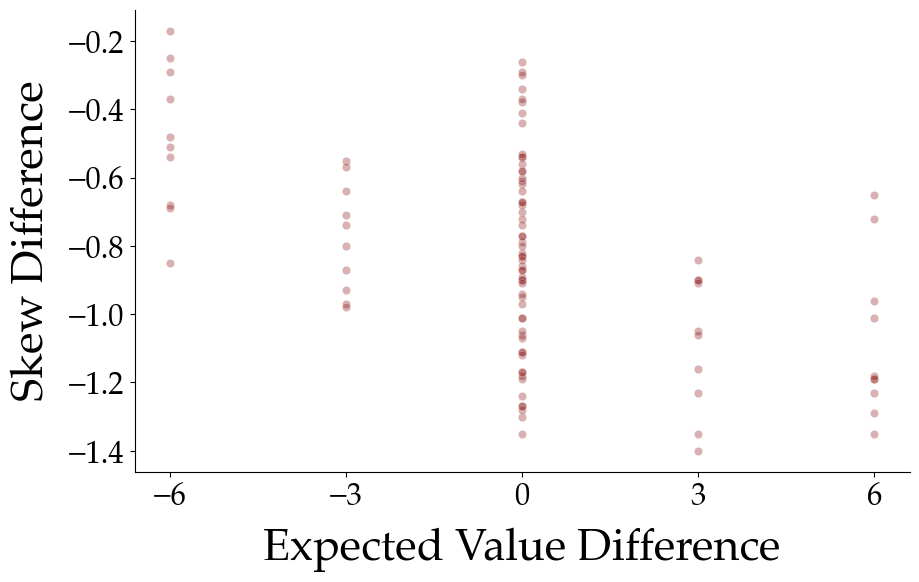

In [39]:
# Create the figure and subplots
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the data
sns.scatterplot(data=df, x="ev_diff", y="skew_diff", color='maroon', alpha=0.3, ax=ax)

# Customize the plot
ax.tick_params(axis='both', which='major', labelsize=FONTSIZE_2)
ax.set_xlabel('Expected Value Difference', fontsize=FONTSIZE_1, labelpad=10)
ax.set_ylabel('Skew Difference', fontsize=FONTSIZE_1, labelpad=10)
ax.set_xticks(np.arange(-6, 7, 3))
sns.despine(ax=ax)

In [ ]:
matched_sets = []  # this will store the final 10 sets
used_indices = {ev: set() for ev in ev_bins}  # to avoid duplicates

# Try each gamble in the first bin as a potential anchor
anchor_ev = ev_bins[0]
anchor_group = bin_groups[anchor_ev]

for idx, anchor_row in anchor_group.iterrows():
    anchor_vec = anchor_row[scaled_features].values.reshape(1, -1)
    
    current_set = {anchor_ev: anchor_row}
    success = True
    
    for other_ev in ev_bins[1:]:
        other_group = bin_groups[other_ev]
        
        # Compute distances to all in this group
        dists = np.linalg.norm(other_group[scaled_features].values - anchor_vec, axis=1)
        within_threshold = np.where(dists < distance_threshold)[0]
        
        # Find first unused matching index
        match_idx = None
        for i in within_threshold:
            if i not in used_indices[other_ev]:
                match_idx = i
                break
        
        if match_idx is not None:
            match_row = other_group.iloc[match_idx]
            current_set[other_ev] = match_row
        else:
            success = False
            break
    
    if success:
        # Mark all indices used
        for ev, row in current_set.items():
            used_indices[ev].add(row.name)
        
        # Store this 7-gamble group
        matched_sets.append(current_set)
    
    if len(matched_sets) >= 10:
        break


In [ ]:
# Ensure 'loss_diff' and 'ev_diff' are numeric
gamble_df['loss_diff'] = pd.to_numeric(gamble_df['loss_diff'], errors='coerce')
gamble_df['loss_diff'] = pd.to_numeric(gamble_df['loss_diff'], errors='coerce')


# Set the tolerance level
tolerance = 0.1
loss_diff_values = gamble_df['loss_diff'].unique()

similar_loss_groups = []

for val in loss_diff_values:
    group = gamble_df[np.isclose(gamble_df['loss_diff'], val, atol=tolerance)]
    ev_diffs = group['ev_diff'].unique()
    if len(ev_diffs) > 1:
        similar_loss_groups.append({
            'base_loss_diff': val,
            'approx_loss_diffs': group['loss_diff'].unique().tolist(),
            'ev_diffs': ev_diffs.tolist()
        })

similar_df = pd.DataFrame(similar_loss_groups)
print(similar_df)

## Loss

In [40]:
ev_diff = np.arange(-9, 9+1, 3)
num_trials = np.array([5] * len(ev_diff))
ev_diff

array([-9, -6, -3,  0,  3,  6,  9])

In [ ]:
columns = [
    "outcome_a1", "outcome_a2", "outcome_a3",
    "outcome_b1", "outcome_b2", "outcome_b3",
    "ev_a", "ev_b", "ev_diff",
    "var_a", "var_b", "var_diff",
    "loss_a", "loss_b", "loss_diff",
    "skew_a", "skew_b", "skew_diff",
]
gamble_df = pd.DataFrame(columns=columns)

In [ ]:
for i in tqdm(range(len(ev_diff))):
    counter = 0
    while True:
        # sample random gamble
        loss = RNG.uniform(-200, -1, 2).astype(np.int32)
        middle = RNG.uniform(-200, -1, 2).astype(np.int32)
        gain = RNG.uniform(1, 200, 2).astype(np.int32)
        gamble_a = np.sort(np.array([loss[0], middle[0], gain[0]]))[::-1]
        gamble_b = np.sort(np.array([loss[1], middle[1], gain[1]]))[::-1]
        # get ev
        ev_a = np.mean(gamble_a)
        ev_b = np.mean(gamble_b)
        # get loss
        loss_a = np.sum(gamble_a[1:])
        loss_b = np.sum(gamble_b[1:])
        # get var
        var_a = np.std(gamble_a)
        var_b = np.std(gamble_b)
        # get skewness
        skew_a = np.round(skew(gamble_a), 2)
        skew_b = np.round(skew(gamble_b), 2)

        utility_la = get_pt_utility(
            2.5, 1,
            np.concatenate([gamble_a, gamble_b])
        )
        utility_ra = get_pt_utility(
            1, 0.6,
            np.concatenate([gamble_a, gamble_b])
        )
        # check if two outcomes are the same
        if len(np.concatenate([gamble_a, gamble_b])) == len(np.unique(np.abs(np.concatenate([gamble_a, gamble_b])))):
            # check for ev diff
            if ev_a - ev_b == ev_diff[i]:
                # check if absolute loss_diff is between -5 and 20
                # if np.abs(loss_a - loss_b) <= 20 and np.abs(loss_a - loss_b) >= 4:
                # check if absolute var_diff is between 2 and 12
                # if np.abs(var_a - var_b) <= 12 and np.abs(var_a - var_b) >= 2:
                # check if spread is larger for high variance option
                # if (np.max(gamble_a) + np.abs(np.min(gamble_a))) < (np.max(gamble_b) + np.abs(np.min(gamble_b))):
                # check for loss and var confound
                if loss_a < loss_b and var_a < var_b:
                    # check if both evs are positive
                    # if ev_a > 0 and ev_b > 0:
                    if i > 1 and i < 5:
                        if utility_la[0] < utility_la[1] and utility_ra[0] > utility_ra[1]:
                            gamble = [
                                {                            
                                    "outcome_a1": gamble_a[0], "outcome_a2": gamble_a[1],
                                    "outcome_a3": gamble_a[2], "outcome_b1": gamble_b[0],
                                    "outcome_b2": gamble_b[1], "outcome_b3": gamble_b[2],
                                    "ev_a": ev_a, "ev_b": ev_b, "ev_diff": ev_a - ev_b,
                                    "var_a": var_a, "var_b": var_b, "var_diff": var_a - var_b,
                                    "loss_a": loss_a, "loss_b": loss_b, "loss_diff": loss_a - loss_b,
                                    "skew_a": skew_a, "skew_b": skew_b, "skew_diff": skew_a - skew_b
                                }
                            ]
                            gamble_df = pd.concat([gamble_df, pd.DataFrame(gamble)], ignore_index=True)
                            counter += 1
                            print(counter)
                            if counter == num_trials[i]:
                                break
                    else:
                        gamble = [
                                {                            
                                    "outcome_a1": gamble_a[0], "outcome_a2": gamble_a[1],
                                    "outcome_a3": gamble_a[2], "outcome_b1": gamble_b[0],
                                    "outcome_b2": gamble_b[1], "outcome_b3": gamble_b[2],
                                    "ev_a": ev_a, "ev_b": ev_b, "ev_diff": ev_a - ev_b,
                                    "var_a": var_a, "var_b": var_b, "var_diff": var_a - var_b,
                                    "loss_a": loss_a, "loss_b": loss_b, "loss_diff": loss_a - loss_b,
                                    "skew_a": skew_a, "skew_b": skew_b, "skew_diff": skew_a - skew_b
                                }
                            ]
                        gamble_df = pd.concat([gamble_df, pd.DataFrame(gamble)], ignore_index=True)
                        counter += 1
                        print(counter)
                        if counter == num_trials[i]:
                            break

In [ ]:
gamble_df

In [ ]:
gamble_df.to_csv(f"../data/lotteries_gain_new_losses.csv", index=False)

In [ ]:
lottery_a = np.array([120, -81, -135])
lottery_b = np.array([131, -43, -157])

In [ ]:
get_pt_utility(2.5, 1, np.concatenate([lottery_a, lottery_b]))

In [ ]:
get_pt_utility(1, 0.6, np.concatenate([lottery_a, lottery_b]))

## Old Lotteries

In [ ]:
ev_diff = np.arange(-6, 6+1, 3)
num_trials = np.array([10, 10, 60, 10, 10])

In [ ]:
columns = [
    "outcome_a1", "outcome_a2", "outcome_a3",
    "outcome_b1", "outcome_b2", "outcome_b3",
    "ev_a", "ev_b", "ev_diff",
    "var_a", "var_b", "var_diff",
    "loss_a", "loss_b", "loss_diff",
    "skew_a", "skew_b", "skew_diff",
]
gamble_df = pd.DataFrame(columns=columns)

In [ ]:
for i in tqdm(range(len(ev_diff))):
    counter = 0
    while True:
        # sample random gamble
        loss = RNG.uniform(-100, -1, 2).astype(np.int32)
        middle = RNG.uniform(1, 100, 2).astype(np.int32)
        gain = RNG.uniform(1, 100, 2).astype(np.int32)
        gamble_a = np.sort(np.array([loss[0], middle[0], gain[0]]))[::-1]
        gamble_b = np.sort(np.array([loss[1], middle[1], gain[1]]))[::-1]
        # get ev
        ev_a = np.mean(gamble_a)
        ev_b = np.mean(gamble_b)
        # get loss
        loss_a = np.min(gamble_a)
        loss_b = np.min(gamble_b)
        # get var
        var_a = np.std(gamble_a)
        var_b = np.std(gamble_b)
        # get skewness
        skew_a = np.round(skew(gamble_a), 2)
        skew_b = np.round(skew(gamble_b), 2)

        utility_la = get_pt_utility(
            2.5, 1,
            np.concatenate([gamble_a, gamble_b])
        )
        utility_ra = get_pt_utility(
            1, 0.6,
            np.concatenate([gamble_a, gamble_b])
        )
        # check if two outcomes are the same
        if len(np.concatenate([gamble_a, gamble_b])) == len(np.unique(np.abs(np.concatenate([gamble_a, gamble_b])))):
            # check for ev diff
            if ev_a - ev_b == ev_diff[i]:
                if ev_a > 0 and ev_b > 0:
                    # check if absolute loss_diff is between -5 and 20
                    if np.abs(loss_a - loss_b) <= 20 and np.abs(loss_a - loss_b) >= 4:
                        # check if absolute var_diff is between 2 and 12
                        if np.abs(var_a - var_b) <= 12 and np.abs(var_a - var_b) >= 2:
                        # check if spread is larger for high variance option
                        # if (np.max(gamble_a) + np.abs(np.min(gamble_a))) < (np.max(gamble_b) + np.abs(np.min(gamble_b))):
                            # check for loss and var confound
                            if loss_a < loss_b and var_a > var_b:
                                if i > 0 and i < 4:
                                    if utility_la[0] < utility_la[1] and utility_ra[0] < utility_ra[1]:
                                        gamble = [
                                            {                            
                                                "outcome_a1": gamble_a[0], "outcome_a2": gamble_a[1],
                                                "outcome_a3": gamble_a[2], "outcome_b1": gamble_b[0],
                                                "outcome_b2": gamble_b[1], "outcome_b3": gamble_b[2],
                                                "ev_a": ev_a, "ev_b": ev_b, "ev_diff": ev_a - ev_b,
                                                "var_a": var_a, "var_b": var_b, "var_diff": var_a - var_b,
                                                "loss_a": loss_a, "loss_b": loss_b, "loss_diff": loss_a - loss_b,
                                                "skew_a": skew_a, "skew_b": skew_b, "skew_diff": skew_a - skew_b
                                            }
                                        ]
                                        gamble_df = pd.concat([gamble_df, pd.DataFrame(gamble)], ignore_index=True)
                                        counter += 1
                                        if counter == num_trials[i]:
                                            break
                                else:
                                    gamble = [
                                            {                            
                                                "outcome_a1": gamble_a[0], "outcome_a2": gamble_a[1],
                                                "outcome_a3": gamble_a[2], "outcome_b1": gamble_b[0],
                                                "outcome_b2": gamble_b[1], "outcome_b3": gamble_b[2],
                                                "ev_a": ev_a, "ev_b": ev_b, "ev_diff": ev_a - ev_b,
                                                "var_a": var_a, "var_b": var_b, "var_diff": var_a - var_b,
                                                "loss_a": loss_a, "loss_b": loss_b, "loss_diff": loss_a - loss_b,
                                                "skew_a": skew_a, "skew_b": skew_b, "skew_diff": skew_a - skew_b
                                            }
                                        ]
                                    gamble_df = pd.concat([gamble_df, pd.DataFrame(gamble)], ignore_index=True)
                                    counter += 1
                                    if counter == num_trials[i]:
                                        break
                            
gamble_df.to_csv(f"../data/lotteries_gain_old.csv", index=False)

## Lotteries Inspection

In [ ]:
lotteries_new = pd.read_csv("../data/lotteries_gain_new.csv")
lotteries_old = pd.read_csv("../data/lotteries_gain_old.csv")

context_new = lotteries_new[[
    'outcome_a1', 'outcome_a2', 'outcome_a3',
    'outcome_b1', 'outcome_b2', 'outcome_b3'
]].to_numpy()

context_old = lotteries_old[[
    'outcome_a1', 'outcome_a2', 'outcome_a3',
    'outcome_b1', 'outcome_b2', 'outcome_b3'
]].to_numpy()

In [ ]:
rows_as_tuples = [tuple(row) for row in context_new]
all_unique = len(rows_as_tuples) == len(set(rows_as_tuples))
print("All rows are unique:", all_unique)

In [ ]:
rows_as_tuples = [tuple(row) for row in context_old]
all_unique = len(rows_as_tuples) == len(set(rows_as_tuples))
print("All rows are unique:", all_unique)

In [ ]:
# Create the figure and subplots
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the data
sns.scatterplot(data=lotteries_new, x="ev_diff", y="loss_diff", color='maroon', label='New', alpha=0.3, ax=ax)
sns.scatterplot(data=lotteries_old, x="ev_diff", y="loss_diff", color='#005F99', label='Old', alpha=0.1, ax=ax)

# Customize the plot
ax.tick_params(axis='both', which='major', labelsize=FONTSIZE_2)
ax.set_xlabel('Expected Value Difference', fontsize=FONTSIZE_1, labelpad=10)
ax.set_ylabel('Loss Difference', fontsize=FONTSIZE_1, labelpad=10)
# ax.set_ylim(-20, 0)
sns.despine(ax=ax)

In [ ]:
# Create the figure and subplots
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the data
sns.scatterplot(data=lotteries_new, x="ev_diff", y="var_diff", color='maroon', label='New', alpha=0.5, ax=ax)
sns.scatterplot(data=lotteries_old, x="ev_diff", y="var_diff", color='#005F99', label='Old', alpha=0.5, ax=ax)

# Customize the plot
ax.tick_params(axis='both', which='major', labelsize=FONTSIZE_2)
ax.set_xlabel('Expected Value Difference', fontsize=FONTSIZE_1, labelpad=10)
ax.set_ylabel('Variance Difference', fontsize=FONTSIZE_1, labelpad=10)
# ax.set_ylim(-20, 0)
sns.despine(ax=ax)

In [ ]:
# Create the figure and subplots
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the data
sns.scatterplot(data=lotteries_new, x="loss_diff", y="var_diff", color='maroon', label='New', alpha=0.5, ax=ax)
sns.scatterplot(data=lotteries_old, x="loss_diff", y="var_diff", color='#005F99', label='Old', alpha=0.5, ax=ax)

# Customize the plot
ax.tick_params(axis='both', which='major', labelsize=FONTSIZE_2)
ax.set_xlabel('Loss Difference', fontsize=FONTSIZE_1, labelpad=10)
ax.set_ylabel('Variance Difference', fontsize=FONTSIZE_1, labelpad=10)
# ax.set_ylim(-20, 0)
sns.despine(ax=ax)

In [ ]:
sns.histplot(data=lotteries_new, x="ev_a", color='maroon', alpha=0.5)
sns.histplot(data=lotteries_new, x="ev_b", color='blue', alpha=0.5)

sns.histplot(data=lotteries_old, x="ev_a", color='green', alpha=0.5)
sns.histplot(data=lotteries_old, x="ev_b", color='yellow', alpha=0.5)